# Phase 10 — Stress Testing
Runs historical scenario replay (real market data from past crises) and hypothetical/parametric shocks against the portfolio. All logic lives in `src/stress_testing/`, this notebook only calls it and shows results.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt

from src.data_collection import config
from src.data_collection.saver import save_processed
from src.data_collection.sectors import get_sector_map
from src.portfolio.weights import equal_weights
from src.stress_testing.engine import run_all_stress_tests, rank_scenarios
from src.visualization import stress_testing_charts

## Load Phase 2/3 outputs (asset returns and portfolio returns)

In [2]:
returns_matrix = pd.read_csv(
    config.DATA_PROCESSED_DIR / 'returns_clean_winsorized.csv',
    index_col=0, parse_dates=True
)
portfolio_returns = pd.read_csv(
    config.DATA_PROCESSED_DIR / 'portfolio_returns_phase3.csv',
    index_col=0, parse_dates=True
).iloc[:, 0]

weights = equal_weights(list(returns_matrix.columns))
PORTFOLIO_VALUE = 1_000_000.0
returns_matrix.tail()

,AAPL,MSFT,NVDA,JPM,XOM,AMZN,META,GOOGL,TSLA,UNH
date,,,,,,,,,,
2026-07-16,0.017435,0.013731,-0.024293,-0.010898,0.009915,-0.020086,-0.024922,-0.045391,-0.008657,0.011545
2026-07-17,0.001439,-0.018317,-0.022380,-0.005992,0.009615,-0.010702,-0.028280,-0.021934,-0.026482,0.006380
2026-07-20,-0.021657,0.021279,0.002315,-0.006559,0.006763,0.011102,-0.000248,0.014941,-0.030039,-0.010712
2026-07-21,0.003515,-0.011350,0.019534,0.018594,0.022329,-0.009808,-0.003164,-0.013846,0.025011,0.034506
2026-07-22,-0.005661,-0.018806,0.022750,0.008595,0.017900,-0.010967,-0.026186,-0.014683,-0.013069,-0.011618


## Get sector classifications (needed for the sector-specific shock)

In [3]:
sector_map = get_sector_map(list(returns_matrix.columns))
sector_map

{'AAPL': 'Technology',
 'MSFT': 'Technology',
 'NVDA': 'Technology',
 'JPM': 'Financial Services',
 'XOM': 'Energy',
 'AMZN': 'Consumer Cyclical',
 'META': 'Communication Services',
 'GOOGL': 'Communication Services',
 'TSLA': 'Consumer Cyclical',
 'UNH': 'Healthcare'}

## Run all stress tests
This downloads real historical price data for each crisis window (needs internet), so it may take a little while the first time.

In [4]:
stress_table = run_all_stress_tests(
    portfolio_returns, returns_matrix, weights, sector_map,
    portfolio_value=PORTFOLIO_VALUE, confidence_level=0.95,
    include_historical=True,
)
stress_table

$TSLA: possibly delisted; no price data found  (1d 2008-09-01 -> 2009-03-09) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1236571200")
$META: possibly delisted; no price data found  (1d 2008-09-01 -> 2009-03-09) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1236571200")

2 Failed downloads:
['TSLA', 'META']: possibly delisted; no price data found  (1d 2008-09-01 -> 2009-03-09) (Yahoo error = "Data doesn't exist for startDate = 1220241600, endDate = 1236571200")


,category,stressed_return,stressed_loss,stressed_var,stressed_es
scenario,,,,,
2008 Financial Crisis,Historical,-0.294802,294801.617506,NaN,NaN
COVID Crash 2020,Historical,-0.336893,336892.857249,NaN,NaN
Inflation Shock 2022,Historical,-0.265702,265701.547493,NaN,NaN
Banking Stress 2023,Historical,0.059950,-59949.654637,NaN,NaN
Tech Selloff Scenario,Historical,-0.267348,267348.012949,NaN,NaN
Equity market down 5%,Hypothetical,-0.050000,50000.000000,NaN,NaN
Equity market down 10%,Hypothetical,-0.100000,100000.000000,NaN,NaN
Equity market down 20%,Hypothetical,-0.200000,200000.000000,NaN,NaN
Volatility doubles,Hypothetical,NaN,47683.291709,0.047683,0.067362


In [5]:
ranked = rank_scenarios(stress_table)
ranked

,rank,category,stressed_return,stressed_loss,stressed_var,stressed_es
scenario,,,,,,
COVID Crash 2020,1,Historical,-0.336893,336892.857249,NaN,NaN
2008 Financial Crisis,2,Historical,-0.294802,294801.617506,NaN,NaN
Tech Selloff Scenario,3,Historical,-0.267348,267348.012949,NaN,NaN
Inflation Shock 2022,4,Historical,-0.265702,265701.547493,NaN,NaN
Equity market down 20%,5,Hypothetical,-0.200000,200000.000000,NaN,NaN
Equity market down 10%,6,Hypothetical,-0.100000,100000.000000,NaN,NaN
Sector-specific shock (Technology -20%),7,Hypothetical,-0.060000,60000.000000,NaN,NaN
Equity market down 5%,8,Hypothetical,-0.050000,50000.000000,NaN,NaN
Volatility doubles,9,Hypothetical,NaN,47683.291709,0.047683,0.067362


## Charts

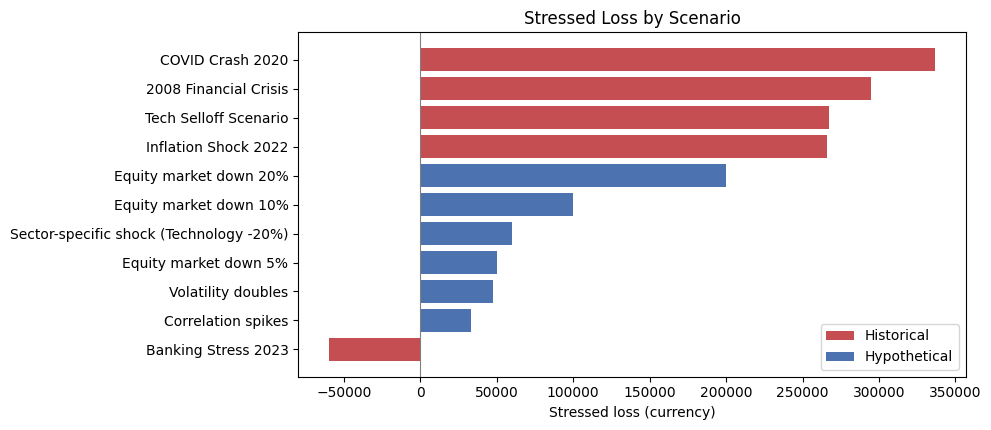

In [6]:
fig1 = stress_testing_charts.plot_scenario_loss_bar(stress_table)
plt.show()

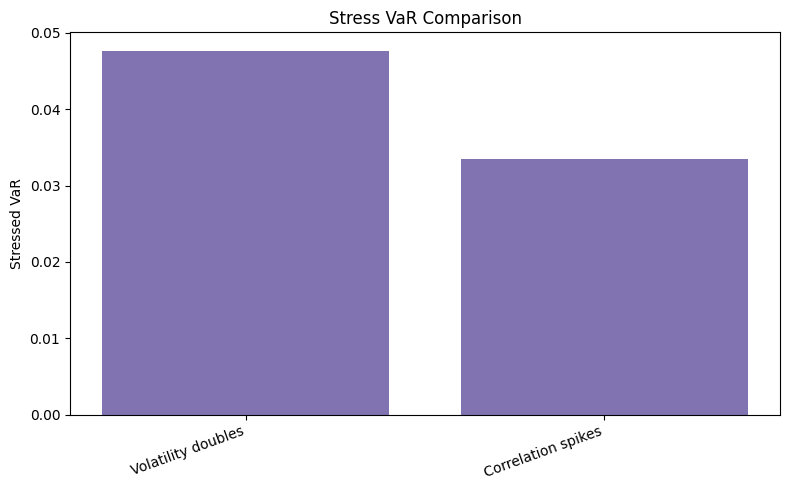

In [7]:
fig2 = stress_testing_charts.plot_stress_var_comparison(stress_table)
plt.show()

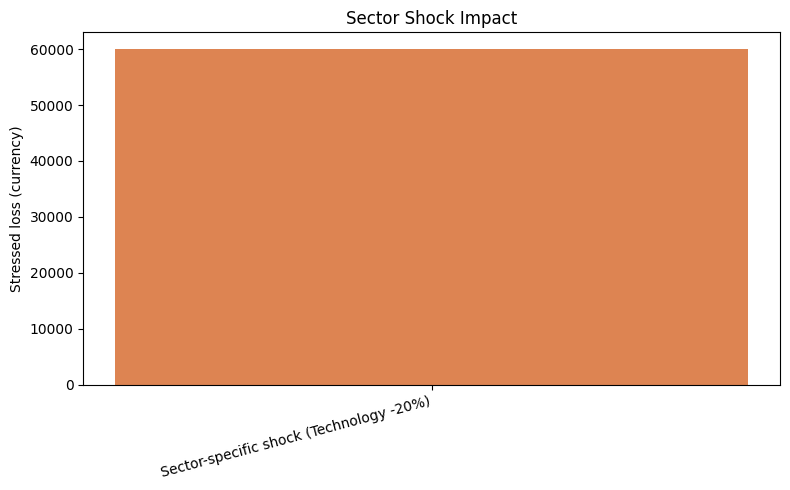

In [8]:
fig3 = stress_testing_charts.plot_sector_shock_impact(stress_table)
plt.show()

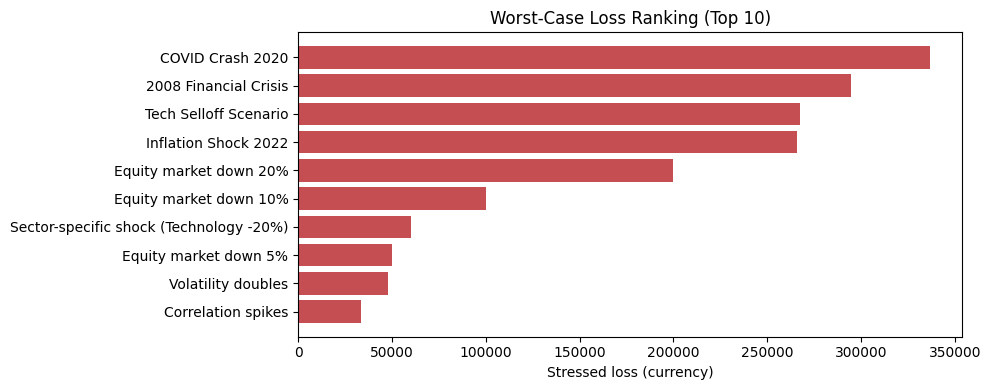

In [9]:
fig4 = stress_testing_charts.plot_worst_loss_ranking(ranked)
plt.show()

## Save Phase 10 outputs

In [10]:
save_processed(stress_table, 'stress_test_results.csv', config.DATA_PROCESSED_DIR)
save_processed(ranked, 'stress_test_ranking.csv', config.DATA_PROCESSED_DIR)
print('Phase 10 outputs saved.')

Phase 10 outputs saved.
